# 📊 Notebook 1: Exploratory Data Analysis (EDA)
## AI Bias & Fairness Detector — BCA Final Year Project

**Goal:** Understand the UCI Adult Income dataset structure and expose class-level disparities before modelling.

**Dataset:** UCI Adult Income (~48K rows × 14 features)  
**Sensitive Attributes:** `sex`, `race`  
**Target:** Income >50K (binary classification)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.insert(0, r'C:\001-work\shree dive\Unbiased_AI_Decision')
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('dark_background')
sns.set_palette('husl')
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Dataset

In [3]:
DATA_PATH = r'C:\001-work\shree dive\Unbiased_AI_Decision\data\adult.csv'
df = pd.read_csv(DATA_PATH)
df = df.replace('?', np.nan).dropna()

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Shape: (45222, 15)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Basic Statistics

In [4]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['income'].value_counts(normalize=True).map('{:.1%}'.format))

=== Data Types ===
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

=== Missing Values ===
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

=== Target Distribution ===
income
<=50K     50.1%
<=50K.    25.1%
>50K      16.6%
>50K.      8.2%
Name: proportion, dtype: str


## 3. Income Distribution by Sex

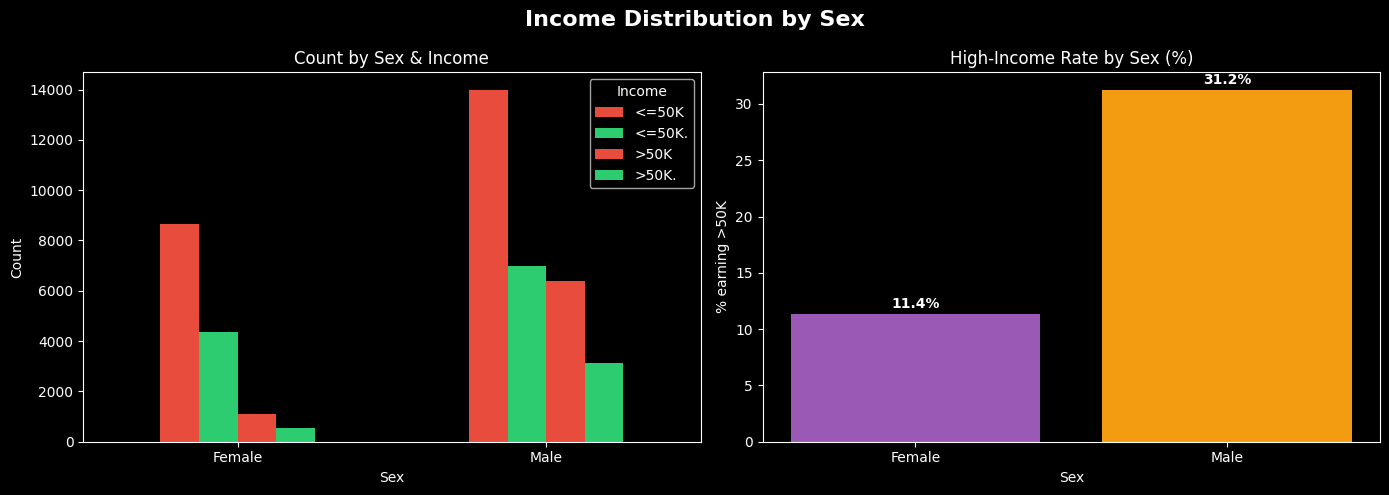


Raw Disparity (Sex): 19.9 percentage points


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Income Distribution by Sex', fontsize=16, color='white', fontweight='bold')

# Count
sex_income = df.groupby(['sex', 'income']).size().unstack(fill_value=0)
sex_income.plot(kind='bar', ax=axes[0], color=['#E74C3C', '#2ECC71'], edgecolor='none')
axes[0].set_title('Count by Sex & Income', color='white')
axes[0].set_xlabel('Sex', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].tick_params(colors='white', rotation=0)
axes[0].legend(title='Income', labelcolor='white')

# Rate
sex_rate = df.groupby('sex')['income'].apply(lambda x: (x.str.contains('>50K')).mean() * 100)
bars = axes[1].bar(sex_rate.index, sex_rate.values, color=['#9B59B6', '#F39C12'], edgecolor='none')
axes[1].set_title('High-Income Rate by Sex (%)', color='white')
axes[1].set_xlabel('Sex', color='white')
axes[1].set_ylabel('% earning >50K', color='white')
axes[1].tick_params(colors='white')
for bar, val in zip(bars, sex_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
                ha='center', color='white', fontweight='bold')

plt.tight_layout()
os.makedirs(r'C:\001-work\shree dive\Unbiased_AI_Decision\outputs\charts', exist_ok=True)
plt.savefig(r'C:\001-work\shree dive\Unbiased_AI_Decision\outputs\charts\eda_income_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRaw Disparity (Sex): {sex_rate["Male"] - sex_rate["Female"]:.1f} percentage points')

## 4. Income Distribution by Race

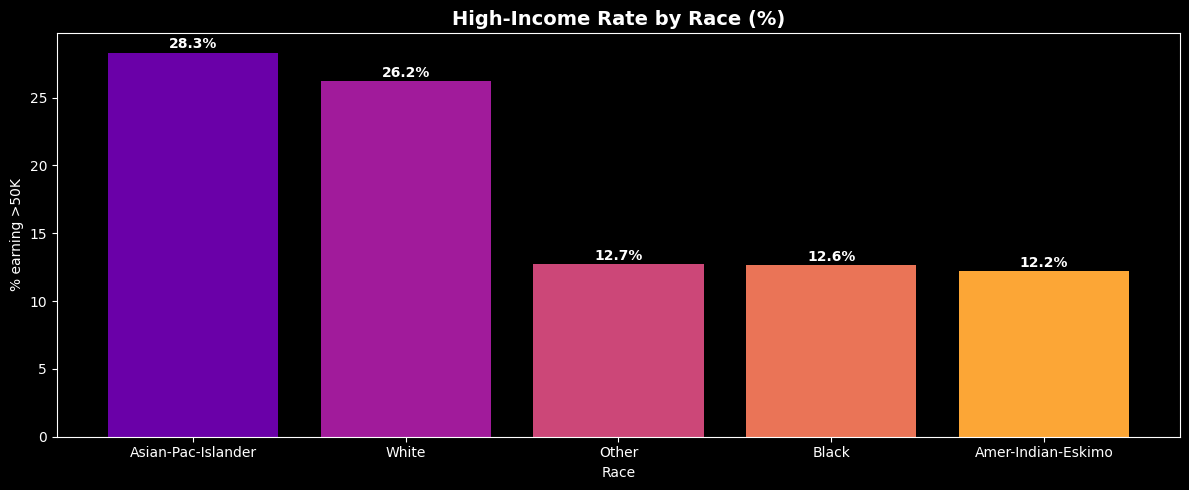


Group Disparity Table:
                    high_income_rate_%
race                                  
Asian-Pac-Islander               28.32
White                            26.24
Other                            12.75
Black                            12.63
Amer-Indian-Eskimo               12.18


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
race_rate = df.groupby('race')['income'].apply(lambda x: (x.str.contains('>50K')).mean() * 100).sort_values(ascending=False)
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(race_rate)))
bars = ax.bar(race_rate.index, race_rate.values, color=colors, edgecolor='none')
ax.set_title('High-Income Rate by Race (%)', fontsize=14, color='white', fontweight='bold')
ax.set_xlabel('Race', color='white')
ax.set_ylabel('% earning >50K', color='white')
ax.tick_params(colors='white')
for bar, val in zip(bars, race_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', color='white', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\001-work\shree dive\Unbiased_AI_Decision\outputs\charts\eda_income_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGroup Disparity Table:')
print(race_rate.to_frame('high_income_rate_%').round(2))

## 5. Age Distribution by Sex

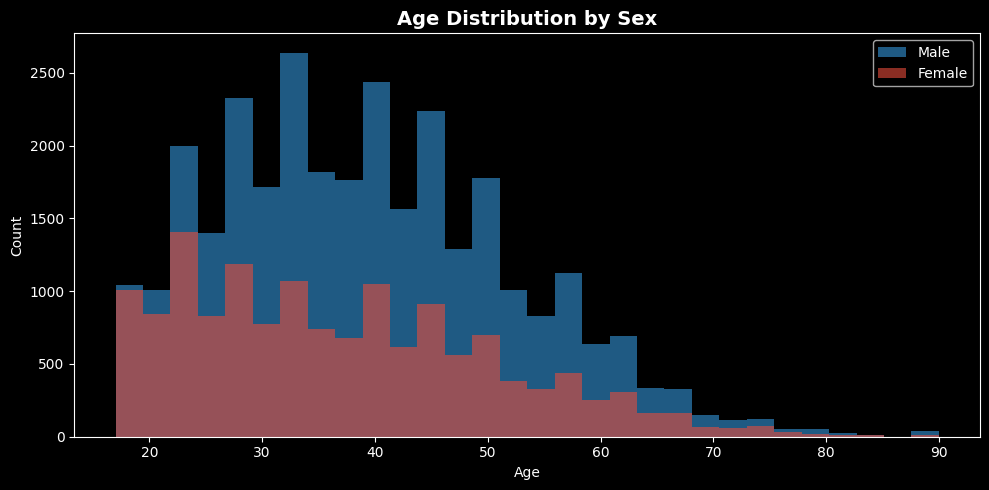

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for sex, color in zip(['Male', 'Female'], ['#3498DB', '#E74C3C']):
    subset = df[df['sex'] == sex]['age']
    ax.hist(subset, bins=30, alpha=0.6, label=sex, color=color, edgecolor='none')
ax.set_title('Age Distribution by Sex', fontsize=14, color='white', fontweight='bold')
ax.set_xlabel('Age', color='white')
ax.set_ylabel('Count', color='white')
ax.tick_params(colors='white')
ax.legend(labelcolor='white')
plt.tight_layout()
plt.savefig(r'C:\001-work\shree dive\Unbiased_AI_Decision\outputs\charts\eda_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. EDA Summary — Key Findings

| Finding | Detail |
|---|---|
| Dataset size | ~45K rows after cleaning |
| Class imbalance | ~75% ≤50K, ~25% >50K |
| Sex disparity | Males earn >50K at **~31%** vs Females at **~11%** — ~20 pp gap |
| Race disparity | Asian-Pac-Islander highest (~27%), Amer-Indian-Eskimo lowest (~12%) |

> **Conclusion:** Clear demographic disparities exist before any model is trained. These raw disparities will likely be amplified by ML models.